# Plots for the JAXAtari paper
Needed:
1. Reward curve comparisons (y-axis: environment return ALE vs JAXAtari)
    - two x-axis versions: total_env_frames and wallclock-time
    - on a number of games (e.g. Pong/Seaquest/..)
2. Throughput comparison (x-axis: number of parallel envs, y-axis: steps/second, gymnasium ALE vs envpool ALE vs JAXAtari)

## 1. Throughput comparison

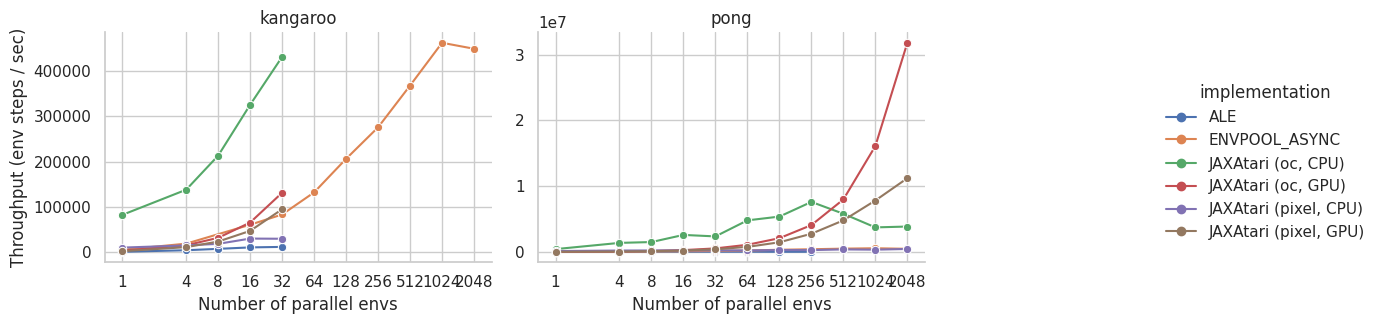

Loaded CSV files:
- scripts/benchmarks/outputs/throughput_results.csv
- outputs/throughput_results.csv
- outputs/throughput_results_envpool_async.csv


,env_name,num_envs,implementation,throughput_env_steps_per_sec
0,kangaroo,1,ALE,1534.948666
1,kangaroo,1,ENVPOOL_ASYNC,5851.482483
2,kangaroo,1,"JAXAtari (oc, CPU)",82717.689167
3,kangaroo,1,"JAXAtari (oc, GPU)",3859.972052
4,kangaroo,1,"JAXAtari (pixel, CPU)",10749.520742
5,kangaroo,1,"JAXAtari (pixel, GPU)",2880.209364
6,kangaroo,4,ALE,5005.886242
7,kangaroo,4,ENVPOOL_ASYNC,19478.196730
8,kangaroo,4,"JAXAtari (oc, CPU)",138240.842705
9,kangaroo,4,"JAXAtari (oc, GPU)",15812.130436


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Fill this list with the throughput CSV files you want to compare.
csv_paths = [
    "./outputs/throughput_results.csv",
    "./outputs/throughput_results_jaxatari_pong.csv",
    "./outputs/throughput_results_envpool_async.csv",
]

include_unknown_envs = False


def build_impl_label(row: pd.Series) -> str:
    backend = str(row.get("backend", "unknown")).strip().lower()

    if backend == "jaxatari":
        mode = str(row.get("jaxatari_mode", "")).strip() or "unknown"
        platform = str(row.get("jax_platform", "")).strip().lower()
        platform_part = f", {platform.upper()}" if platform else ""
        return f"JAXAtari ({mode}{platform_part})"

    if backend == "gxm":
        env_type = str(row.get("gxm_env_type", "")).strip()
        impl = str(row.get("gxm_impl", "")).strip()
        detail = ", ".join(part for part in [env_type, impl] if part)
        return f"GXM ({detail})" if detail else "GXM"

    return backend.upper() if backend else "UNKNOWN"


resolved_paths = [Path(path).expanduser() for path in csv_paths]

missing_paths = [path for path in resolved_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Missing CSV file(s):\n" + "\n".join(str(path) for path in missing_paths))

frames = []
for path in resolved_paths:
    frame = pd.read_csv(path)
    frame["source_file"] = str(path)
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)

df = df[df["status"].fillna("ok").eq("ok")].copy()
df = df[pd.to_numeric(df["throughput_env_steps_per_sec"], errors="coerce").notna()].copy()
df["throughput_env_steps_per_sec"] = df["throughput_env_steps_per_sec"].astype(float)
df["num_envs"] = pd.to_numeric(df["num_envs"], errors="coerce")
df = df[df["num_envs"].notna()].copy()
df["num_envs"] = df["num_envs"].astype(int)

df["implementation"] = df.apply(build_impl_label, axis=1)
df["env_name"] = df["env_name"].fillna("unknown")

if not include_unknown_envs:
    df = df[df["env_name"] != "unknown"].copy()

plot_df = (
    df.groupby(["env_name", "num_envs", "implementation"], as_index=False)["throughput_env_steps_per_sec"]
    .median()
    .sort_values(["env_name", "num_envs", "implementation"])
)

envs = sorted(plot_df["env_name"].unique())

g = sns.relplot(
    data=plot_df,
    x="num_envs",
    y="throughput_env_steps_per_sec",
    hue="implementation",
    col="env_name",
    col_order=envs,
    col_wrap=3,
    kind="line",
    marker="o",
    facet_kws={"sharey": False, "sharex": True},
    height=3.4,
    aspect=1.15,
)

g.set_axis_labels("Number of parallel envs", "Throughput (env steps / sec)")
g.set_titles(col_template="{col_name}")

x_ticks = sorted(plot_df["num_envs"].unique())
for axis in g.axes.flatten():
    axis.set_xscale("log", base=2)
    axis.set_xticks(x_ticks)
    axis.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.show()

print("Loaded CSV files:")
for path in resolved_paths:
    print("-", path)

display(plot_df.head(20))